## general description
this Notebook is an explorative analysis of the MD-dataset for the NylC variants. It provides the necessary analysis for deriving mechanistically driven hypothesis of the catalytic activity of NylC.


In [ ]:

from pathlib import Path
import re
import MDAnalysis as mda

# Pfad des aktuellen Skripts
SCRIPT_DIR = Path("/home/dwp46550/ba_nylon/Notebooks/MD_data_loading.ipynb").resolve().parent

# BA_Nylon/
PROJECT_ROOT = SCRIPT_DIR.parent

# BA_Nylon/data/md
base = PROJECT_ROOT / "data" / "md"

print(f"Using MD directory: {base}")

for variant_dir in base.iterdir():

    if not variant_dir.is_dir():
        continue

    variant = variant_dir.name
    print(variant)
    for condition_dir in variant_dir.iterdir():

        if not condition_dir.is_dir():
            continue

        condition = condition_dir.name
        print(condition)
        for xtc_file in sorted(condition_dir.glob("md_center_*.xtc")):

            match = re.search(r"md_center_(\d+)", xtc_file.stem)

            if match is None:
                print(f"Could not detect replicate number from {xtc_file.name}")
                continue

            replicate = int(match.group(1))

            pdb_file = condition_dir / f"md_center_{replicate}.pdb"

            if not pdb_file.exists():
                print(f"Missing matching PDB for {xtc_file.name}")
                continue

            print("\n==============================")
            print(f"Variant: {variant}")
            print(f"Condition: {condition}")
            print(f"Replicate: {replicate}")
            print(f"PDB: {pdb_file.name}")
            print(f"XTC: {xtc_file.name}")

            u = mda.Universe(
                str(pdb_file),
                str(xtc_file)
            )

            print(f"Atoms: {u.atoms.n_atoms}")
            print(f"Frames: {len(u.trajectory)}")
            print("==============================")




In [ ]:
from pathlib import Path
import re
import MDAnalysis as mda
import nglview as nv
from IPython.display import display
from MDAnalysis.coordinates.XTC import XTCWriter

def make_visualization_universe(
    u,
    selection="protein or (not protein and not resname SOL WAT HOH NA CL K)",
    stride=20,
):
    """
    Creates a smaller in-memory Universe for visualization.
    Removes most solvent/ions and keeps only every nth frame.
    """

    atoms = u.select_atoms(selection)

    if atoms.n_atoms == 0:
        raise ValueError(f"Selection returned 0 atoms: {selection}")

    frames = []

    for ts in u.trajectory[::stride]:
        frames.append(atoms.positions.copy())

    u_vis = mda.Merge(atoms)
    u_vis.load_new(frames, order="fac")

    return u_vis


def visualize_universe(
    u,
    variant,
    condition,
    replicate,
    selection="protein and backbone",
    stride=20,
):
    """
    Creates an interactive NGLView visualization from a reduced trajectory.
    """

    print("\n==============================")
    print(f"Variant:   {variant}")
    print(f"Condition: {condition}")
    print(f"Replicate: {replicate}")
    print(f"Original atoms:  {u.atoms.n_atoms}")
    print(f"Original frames: {len(u.trajectory)}")

    u_vis = make_visualization_universe(
        u=u,
        selection=selection,
        stride=stride,
    )

    print(f"Shown atoms:     {u_vis.atoms.n_atoms}")
    print(f"Shown frames:    {len(u_vis.trajectory)}")
    print("==============================")

    view = nv.show_mdanalysis(u_vis)

    view.clear_representations()

    view.add_representation(
        "cartoon",
        selection="protein",
    )

    view.add_representation(
        "licorice",
        selection="not protein",
    )

    view.center()
    view.camera = "orthographic"

    return view


SCRIPT_DIR = Path("/home/dwp46550/ba_nylon/Notebooks/MD_data_loading.ipynb").resolve().parent
PROJECT_ROOT = SCRIPT_DIR.parent
base = PROJECT_ROOT / "data" / "md"

print(f"Using MD directory: {base}")

for variant_dir in base.iterdir():

    if not variant_dir.is_dir():
        continue

    variant = variant_dir.name
    print(variant)

    for condition_dir in variant_dir.iterdir():

        if not condition_dir.is_dir():
            continue

        condition = condition_dir.name
        print(condition)

        for xtc_file in sorted(condition_dir.glob("md_center_*.xtc")):

            match = re.search(r"md_center_(\d+)", xtc_file.stem)

            if match is None:
                print(f"Could not detect replicate number from {xtc_file.name}")
                continue

            replicate = int(match.group(1))
            pdb_file = condition_dir / f"md_center_{replicate}.pdb"

            if not pdb_file.exists():
                print(f"Missing matching PDB for {xtc_file.name}")
                continue

            print("\n==============================")
            print(f"Variant: {variant}")
            print(f"Condition: {condition}")
            print(f"Replicate: {replicate}")
            print(f"PDB: {pdb_file.name}")
            print(f"XTC: {xtc_file.name}")


            u = mda.Universe(
                str(pdb_file),
                str(xtc_file),
            )

            print(f"Atoms: {u.atoms.n_atoms}")
            print(f"Frames: {len(u.trajectory)}")
            print("==============================")

            view = visualize_universe(
                u=u,
                variant=variant,
                condition=condition,
                replicate=replicate,
                stride=20,
            )

            display(view)

In [27]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt


SCRIPT_DIR = Path("/home/dwp46550/ba_nylon/Notebooks/MD_data_loading.ipynb").resolve().parent
PROJECT_ROOT = SCRIPT_DIR.parent
BASE = PROJECT_ROOT / "data" / "md"

OUT_DIR = PROJECT_ROOT / "results" / "md_feature_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STRIDE = 10

print(f"Using MD directory: {BASE}")


def compute_rmsd_for_replicate(
    u,
    variant,
    condition,
    replicate,
    select="protein and backbone",
    ref_frame=0,
    stride=10,
):
    ref = u.copy()
    ref.trajectory[ref_frame]

    if u.select_atoms(select).n_atoms == 0:
        raise ValueError(f"Selection returned 0 atoms: {select}")

    rmsd_analysis = rms.RMSD(
        u,
        ref,
        select=select,
        ref_frame=ref_frame,
    )

    rmsd_analysis.run(step=stride)

    df = pd.DataFrame(
        rmsd_analysis.results.rmsd,
        columns=["frame_index", "time_ps", "rmsd_A"],
    )

    df["variant"] = variant
    df["condition"] = condition
    df["replicate"] = replicate
    df["selection"] = select

    return df[
        [
            "variant",
            "condition",
            "replicate",
            "selection",
            "frame_index",
            "time_ps",
            "rmsd_A",
        ]
    ]


all_rmsd = []

for variant_dir in BASE.iterdir():

    if not variant_dir.is_dir():
        continue

    variant = variant_dir.name

    for condition_dir in variant_dir.iterdir():

        if not condition_dir.is_dir():
            continue

        condition = condition_dir.name

        for xtc_file in sorted(condition_dir.glob("md_center_*.xtc")):

            match = re.search(r"md_center_(\d+)", xtc_file.stem)

            if match is None:
                print(f"Could not detect replicate number from {xtc_file.name}")
                continue

            replicate = int(match.group(1))
            pdb_file = condition_dir / f"md_center_{replicate}.pdb"

            if not pdb_file.exists():
                print(f"Missing matching PDB for {xtc_file.name}")
                continue

            print(f"Processing: {variant} | {condition} | replicate {replicate}")

            u = mda.Universe(str(pdb_file), str(xtc_file))

            rmsd_df = compute_rmsd_for_replicate(
                u=u,
                variant=variant,
                condition=condition,
                replicate=replicate,
                select="protein and backbone",
                ref_frame=0,
                stride=STRIDE,
            )

            all_rmsd.append(rmsd_df)


rmsd_framewise = pd.concat(all_rmsd, ignore_index=True)
rmsd_framewise.to_csv(OUT_DIR / "rmsd_framewise.csv", index=False)

rmsd_replicate = (
    rmsd_framewise
    .groupby(["variant", "condition", "replicate"], as_index=False)
    .agg(
        rmsd_mean_A=("rmsd_A", "mean"),
        rmsd_std_A=("rmsd_A", "std"),
        rmsd_min_A=("rmsd_A", "min"),
        rmsd_max_A=("rmsd_A", "max"),
        n_frames=("rmsd_A", "count"),
    )
)

rmsd_replicate.to_csv(OUT_DIR / "rmsd_replicate.csv", index=False)

rmsd_variant_by_condition = (
    rmsd_replicate
    .groupby(["condition", "variant"], as_index=False)
    .agg(
        rmsd_mean_over_replicates_A=("rmsd_mean_A", "mean"),
        rmsd_sd_between_replicates_A=("rmsd_mean_A", "std"),
        n_replicates=("replicate", "count"),
    )
)

rmsd_variant_by_condition.to_csv(
    OUT_DIR / "rmsd_variant_by_condition.csv",
    index=False,
)

rmsd_variant_by_condition

Using MD directory: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/data/md
Processing: f134w_d304m_r330a | ace_coo | replicate 1
Processing: f134w_d304m_r330a | ace_coo | replicate 2
Processing: f134w_d304m_r330a | ace_coo | replicate 3
Processing: WT | coo_ace | replicate 1
Processing: WT | coo_ace | replicate 2
Processing: WT | coo_ace | replicate 3
Processing: WT | ace_coo | replicate 1
Processing: WT | ace_coo | replicate 2
Processing: WT | ace_coo | replicate 3
Processing: WT | no_substrate | replicate 1
Processing: WT | no_substrate | replicate 2
Processing: WT | no_substrate | replicate 3
Processing: D99R_f134w_d304m_r330a | ace_coo | replicate 1
Processing: D99R_f134w_d304m_r330a | ace_coo | replicate 2
Processing: D99R_f134w_d304m_r330a | ace_coo | replicate 3
Processing: D99R | no_substrate | replicate 1
Processing: D99R | no_substrate | replicate 2
Processing: D99R | no_substrate | replicate 3


,condition,variant,rmsd_mean_over_replicates_A,rmsd_sd_between_replicates_A,n_replicates
0,ace_coo,D99R_f134w_d304m_r330a,1.882578,0.137921,3
1,ace_coo,WT,1.653262,0.126319,3
2,ace_coo,f134w_d304m_r330a,1.755077,0.166139,3
3,coo_ace,WT,1.753323,0.103286,3
4,no_substrate,D99R,1.533102,0.096076,3
5,no_substrate,WT,1.649716,0.209907,3


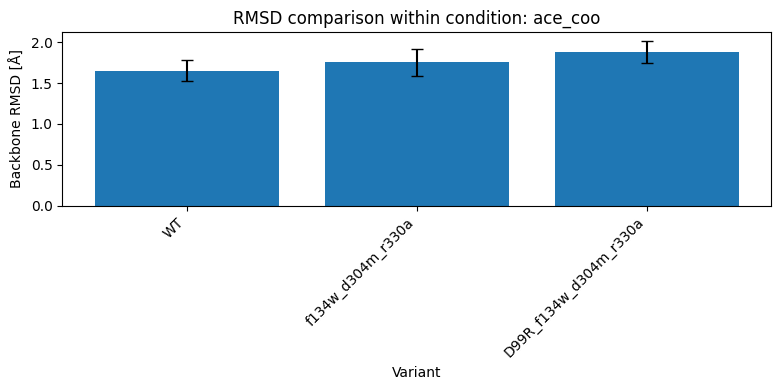

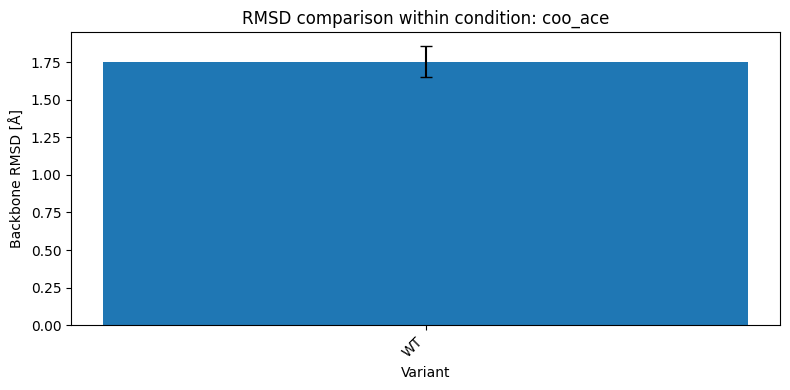

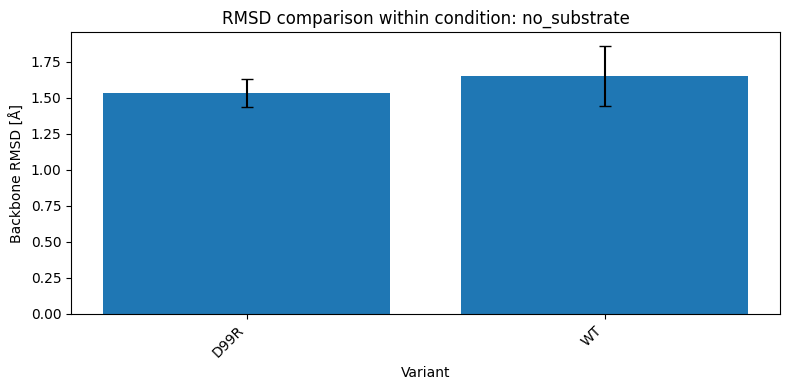

In [28]:
conditions = sorted(rmsd_variant_by_condition["condition"].unique())

for condition_name in conditions:

    plot_df = rmsd_variant_by_condition[
        rmsd_variant_by_condition["condition"] == condition_name
    ].copy()

    plot_df = plot_df.sort_values("rmsd_mean_over_replicates_A")

    plt.figure(figsize=(8, 4))

    plt.bar(
        plot_df["variant"],
        plot_df["rmsd_mean_over_replicates_A"],
        yerr=plot_df["rmsd_sd_between_replicates_A"],
        capsize=4,
    )

    plt.ylabel("Backbone RMSD [Å]")
    plt.xlabel("Variant")
    plt.title(f"RMSD comparison within condition: {condition_name}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

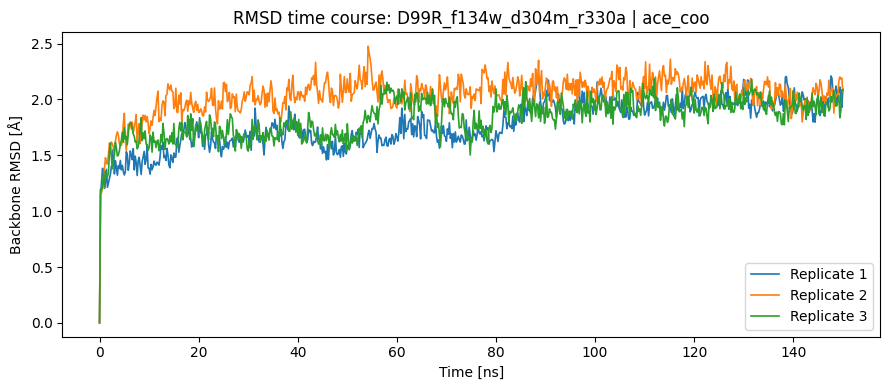

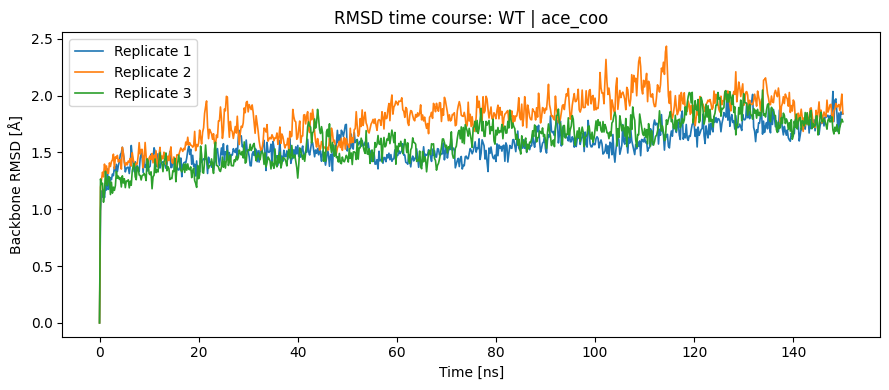

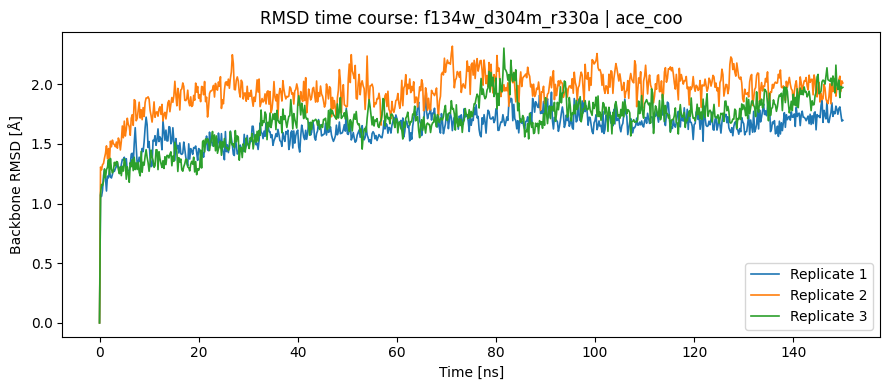

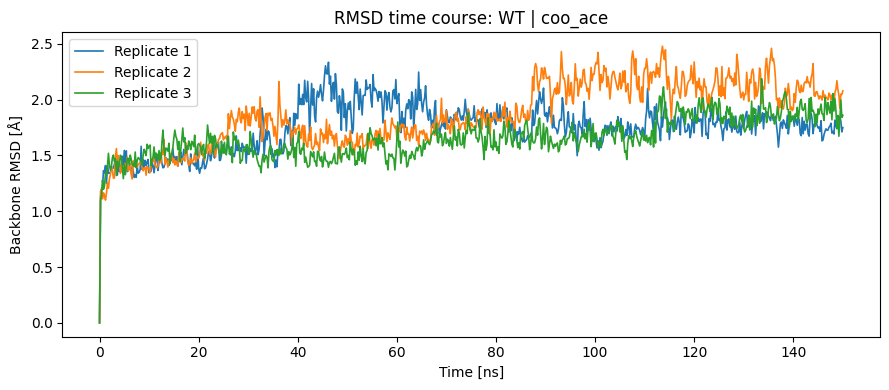

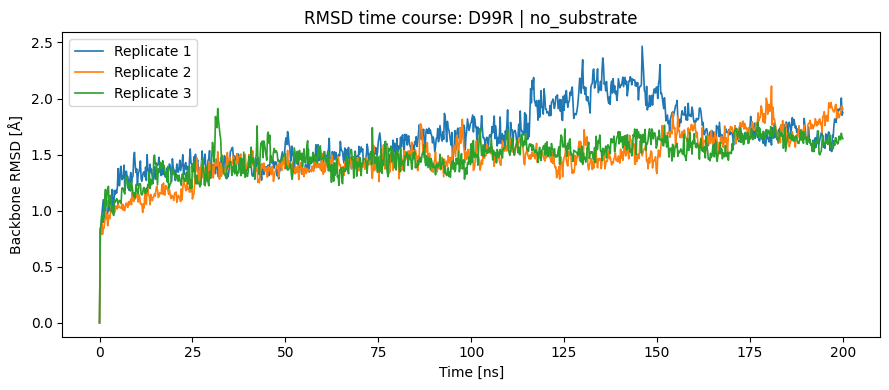

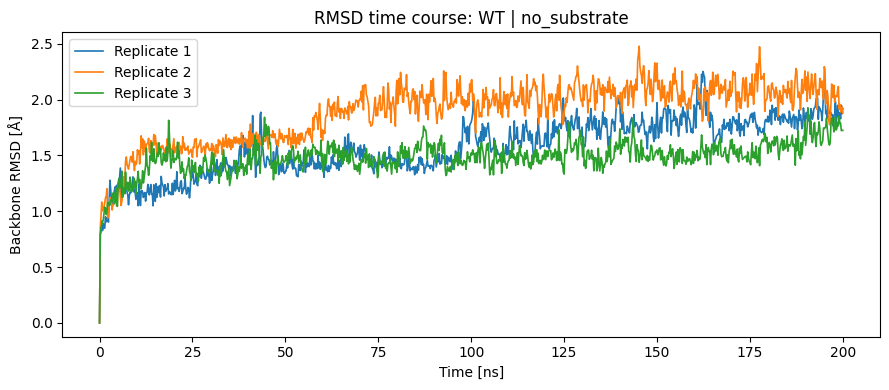

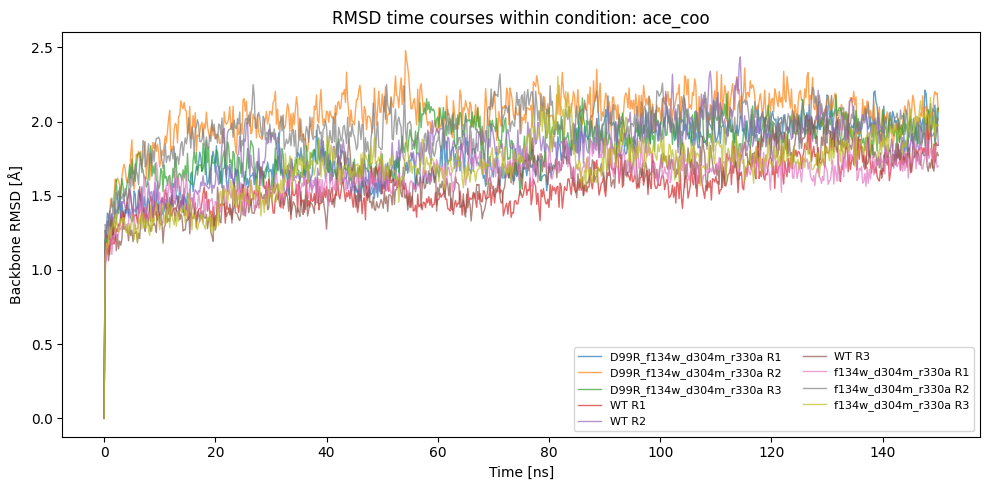

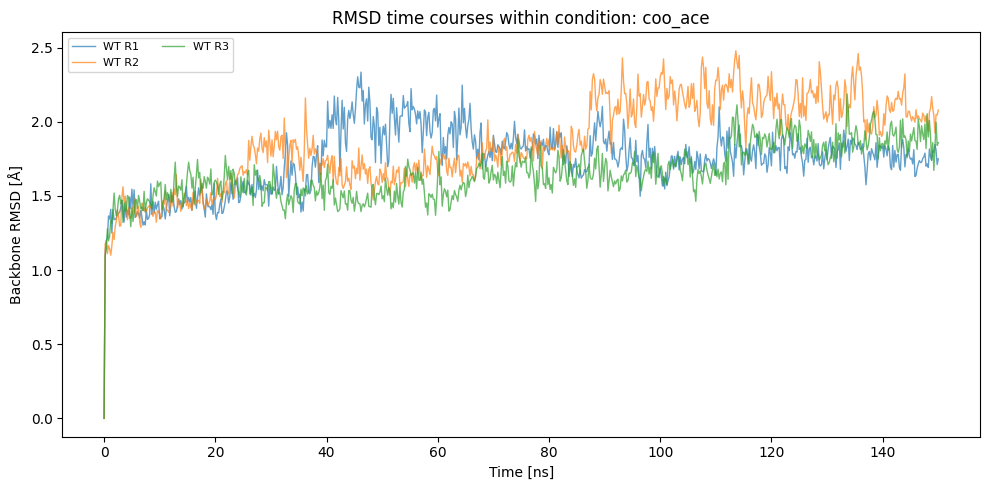

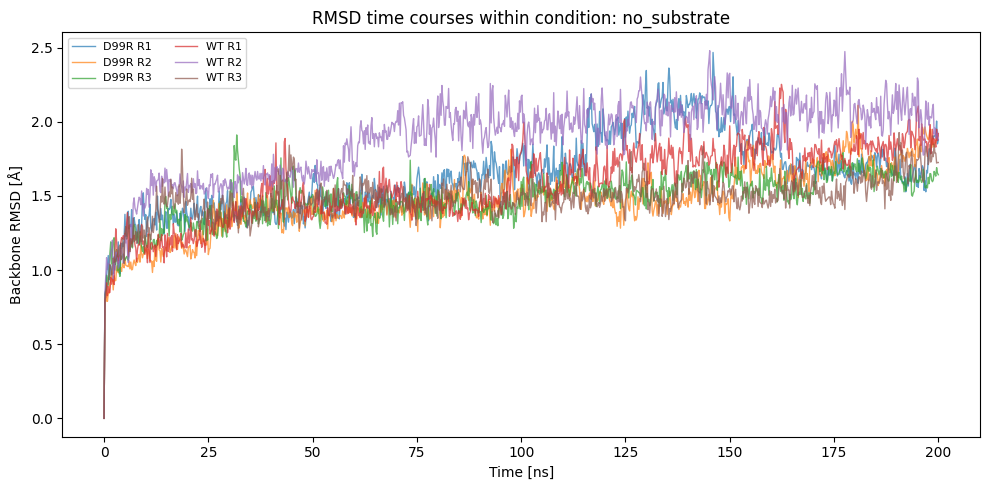

In [30]:
import matplotlib.pyplot as plt

conditions = sorted(rmsd_framewise["condition"].unique())

for condition_name in conditions:

    condition_df = rmsd_framewise[
        rmsd_framewise["condition"] == condition_name
    ].copy()

    variants = sorted(condition_df["variant"].unique())

    for variant in variants:

        plot_df = condition_df[
            condition_df["variant"] == variant
        ].copy()

        plt.figure(figsize=(9, 4))

        for replicate in sorted(plot_df["replicate"].unique()):

            rep_df = plot_df[
                plot_df["replicate"] == replicate
            ].sort_values("time_ps")

            plt.plot(
                rep_df["time_ps"] / 1000,
                rep_df["rmsd_A"],
                label=f"Replicate {replicate}",
                linewidth=1.2,
            )

        plt.xlabel("Time [ns]")
        plt.ylabel("Backbone RMSD [Å]")
        plt.title(f"RMSD time course: {variant} | {condition_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

for condition_name in sorted(rmsd_framewise["condition"].unique()):

    plot_df = rmsd_framewise[
        rmsd_framewise["condition"] == condition_name
    ].copy()

    plt.figure(figsize=(10, 5))

    for (variant, replicate), group in plot_df.groupby(["variant", "replicate"]):

        group = group.sort_values("time_ps")

        plt.plot(
            group["time_ps"] / 1000,
            group["rmsd_A"],
            linewidth=1,
            alpha=0.7,
            label=f"{variant} R{replicate}",
        )

    plt.xlabel("Time [ns]")
    plt.ylabel("Backbone RMSD [Å]")
    plt.title(f"RMSD time courses within condition: {condition_name}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

In [ ]:
ca = u.select_atoms("protein and name CA")

resids = ca.resids

breaks = []

for i in range(1, len(resids)):
    if resids[i] < resids[i - 1]:
        breaks.append(i)

print("Subunit breaks:", breaks)
print("Number of subunits:", len(breaks) + 1)

In [ ]:
import numpy as np

subunit_ids = np.zeros(len(ca), dtype=int)

current_subunit = 1
subunit_ids[0] = current_subunit

for i in range(1, len(ca)):
    if ca.resids[i] < ca.resids[i - 1]:
        current_subunit += 1
    subunit_ids[i] = current_subunit

ca_table = pd.DataFrame({
    "atom_index": ca.indices,
    "resid": ca.resids,
    "resname": ca.resnames,
    "subunit_id": subunit_ids,
})

ca_table.head()

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.analysis import align, rms


def infer_subunit_ids_from_resid_reset(atoms):
    """
    Infers subunit IDs from residue numbering resets.
    Works if subunits are stored consecutively and residue IDs restart.
    """

    resids = atoms.resids
    subunit_ids = np.ones(len(atoms), dtype=int)

    current_subunit = 1

    for i in range(1, len(atoms)):

        if resids[i] < resids[i - 1]:
            current_subunit += 1

        subunit_ids[i] = current_subunit

    return subunit_ids


def compute_rmsf_for_replicate(
    u,
    variant,
    condition,
    replicate,
    align_select="protein and backbone",
    rmsf_select="protein and name CA",
):
    """
    Computes residue-level RMSF for one replicate.
    Trajectory is aligned to the first frame before RMSF calculation.
    Subunits are reconstructed from residue-number resets.
    """

    mobile = u.copy()
    reference = u.copy()
    reference.trajectory[0]

    if mobile.select_atoms(align_select).n_atoms == 0:
        raise ValueError(f"Alignment selection returned 0 atoms: {align_select}")

    aligner = align.AlignTraj(
        mobile,
        reference,
        select=align_select,
        in_memory=True,
    )
    aligner.run()

    atoms = mobile.select_atoms(rmsf_select)

    if atoms.n_atoms == 0:
        raise ValueError(f"RMSF selection returned 0 atoms: {rmsf_select}")

    subunit_ids = infer_subunit_ids_from_resid_reset(atoms)

    rmsf_analysis = rms.RMSF(atoms)
    rmsf_analysis.run()

    df = pd.DataFrame({
        "variant": variant,
        "condition": condition,
        "replicate": replicate,
        "subunit_id": subunit_ids,
        "resid": atoms.resids,
        "resname": atoms.resnames,
        "atom_name": atoms.names,
        "rmsf_A": rmsf_analysis.results.rmsf,
    })

    return df


all_rmsf = []

for variant_dir in BASE.iterdir():

    if not variant_dir.is_dir():
        continue

    variant = variant_dir.name

    for condition_dir in variant_dir.iterdir():

        if not condition_dir.is_dir():
            continue

        condition = condition_dir.name

        for xtc_file in sorted(condition_dir.glob("md_center_*.xtc")):

            match = re.search(r"md_center_(\d+)", xtc_file.stem)

            if match is None:
                print(f"Could not detect replicate number from {xtc_file.name}")
                continue

            replicate = int(match.group(1))
            pdb_file = condition_dir / f"md_center_{replicate}.pdb"

            if not pdb_file.exists():
                print(f"Missing matching PDB for {xtc_file.name}")
                continue

            print(f"Processing RMSF: {variant} | {condition} | replicate {replicate}")

            u = mda.Universe(str(pdb_file), str(xtc_file))

            rmsf_df = compute_rmsf_for_replicate(
                u=u,
                variant=variant,
                condition=condition,
                replicate=replicate,
                align_select="protein and backbone",
                rmsf_select="protein and name CA",
            )

            all_rmsf.append(rmsf_df)

rmsf_replicate = pd.concat(all_rmsf, ignore_index=True)

rmsf_replicate.to_csv(
    OUT_DIR / "rmsf_replicate.csv",
    index=False,
)

rmsf_replicate.head()

Processing RMSF: f134w_d304m_r330a | ace_coo | replicate 1
Processing RMSF: f134w_d304m_r330a | ace_coo | replicate 2
Processing RMSF: f134w_d304m_r330a | ace_coo | replicate 3
Processing RMSF: WT | coo_ace | replicate 1
Processing RMSF: WT | coo_ace | replicate 2
Processing RMSF: WT | coo_ace | replicate 3
Processing RMSF: WT | ace_coo | replicate 1
Processing RMSF: WT | ace_coo | replicate 2
Processing RMSF: WT | ace_coo | replicate 3
Processing RMSF: WT | no_substrate | replicate 1
Processing RMSF: WT | no_substrate | replicate 2
Processing RMSF: WT | no_substrate | replicate 3
Processing RMSF: D99R_f134w_d304m_r330a | ace_coo | replicate 1
Processing RMSF: D99R_f134w_d304m_r330a | ace_coo | replicate 2
Processing RMSF: D99R_f134w_d304m_r330a | ace_coo | replicate 3
Processing RMSF: D99R | no_substrate | replicate 1
Processing RMSF: D99R | no_substrate | replicate 2
Processing RMSF: D99R | no_substrate | replicate 3


,variant,condition,replicate,subunit_id,resid,resname,atom_name,rmsf_A
0,f134w_d304m_r330a,ace_coo,1,1,19,ASP,CA,3.301826
1,f134w_d304m_r330a,ace_coo,1,1,20,PRO,CA,2.334458
2,f134w_d304m_r330a,ace_coo,1,1,21,ALA,CA,1.523967
3,f134w_d304m_r330a,ace_coo,1,1,22,PRO,CA,0.833390
4,f134w_d304m_r330a,ace_coo,1,1,23,ARG,CA,0.694169


In [41]:
rmsf_variant_by_condition = (
    rmsf_replicate
    .groupby(
        ["condition", "variant", "subunit_id", "resid", "resname"],
        as_index=False,
    )
    .agg(
        rmsf_mean_A=("rmsf_A", "mean"),
        rmsf_sd_A=("rmsf_A", "std"),
        n_replicates=("replicate", "count"),
    )
)

rmsf_variant_by_condition.to_csv(
    OUT_DIR / "rmsf_variant_by_condition.csv",
    index=False,
)

rmsf_variant_by_condition.head(20)

,condition,variant,subunit_id,resid,resname,rmsf_mean_A,rmsf_sd_A,n_replicates
0,ace_coo,D99R_f134w_d304m_r330a,1,19,ASP,3.296652,1.063707,3
1,ace_coo,D99R_f134w_d304m_r330a,1,20,PRO,2.272831,0.926594,3
2,ace_coo,D99R_f134w_d304m_r330a,1,21,ALA,1.506302,0.488415,3
3,ace_coo,D99R_f134w_d304m_r330a,1,22,PRO,0.829161,0.082805,3
4,ace_coo,D99R_f134w_d304m_r330a,1,23,ARG,0.696824,0.036522,3
5,ace_coo,D99R_f134w_d304m_r330a,1,24,LEU,0.712758,0.063166,3
6,ace_coo,D99R_f134w_d304m_r330a,1,25,ALA,0.818127,0.097722,3
7,ace_coo,D99R_f134w_d304m_r330a,1,26,GLY,1.251444,0.295039,3
8,ace_coo,D99R_f134w_d304m_r330a,1,27,PRO,1.711412,0.496679,3
9,ace_coo,D99R_f134w_d304m_r330a,1,28,PRO,1.702367,0.470460,3


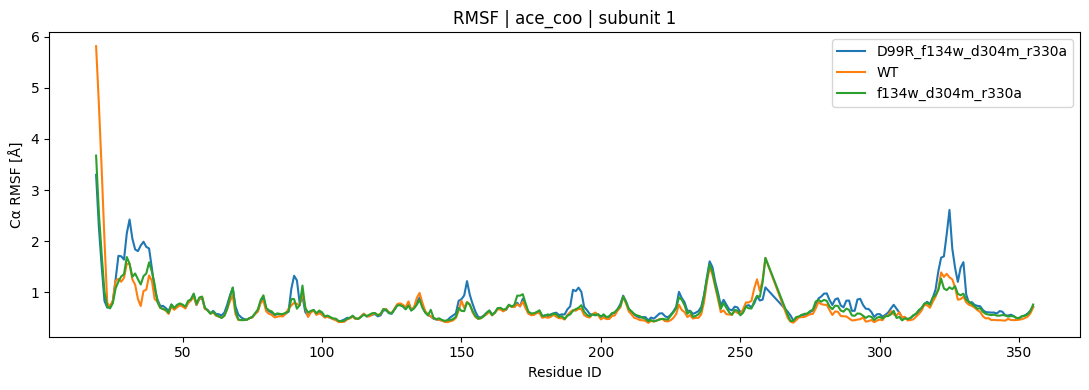

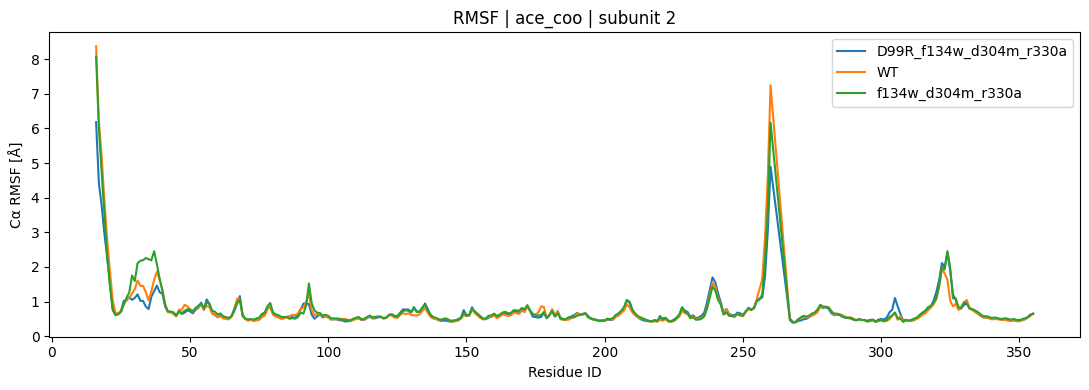

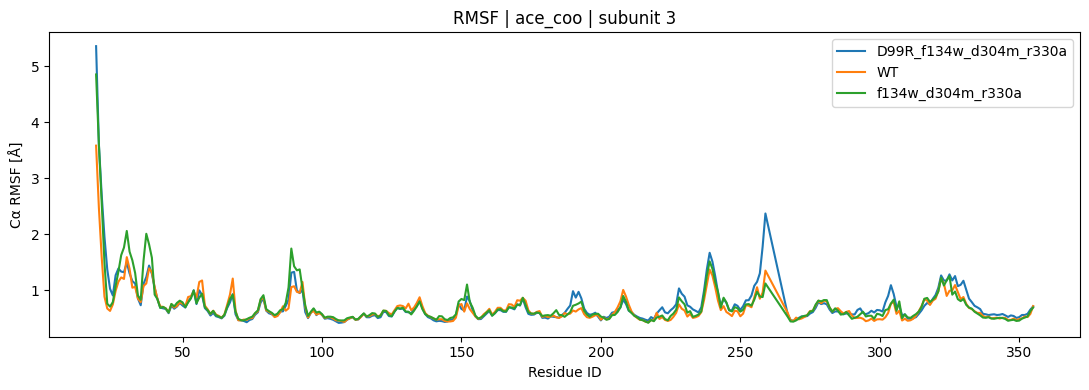

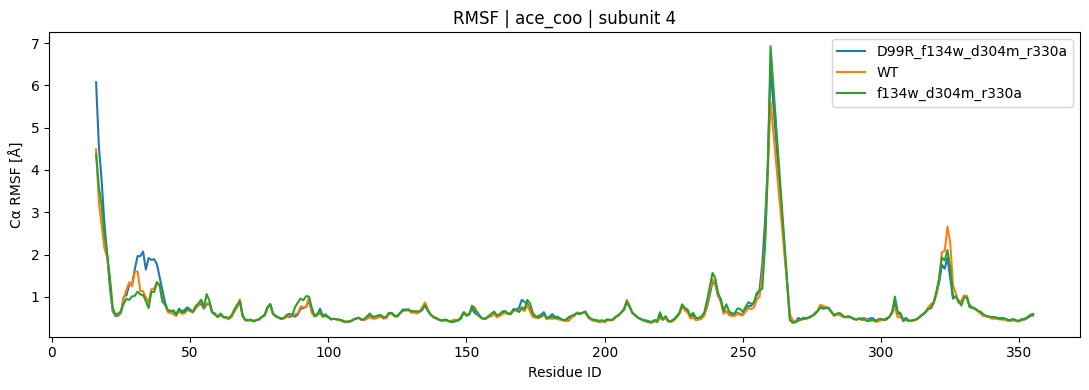

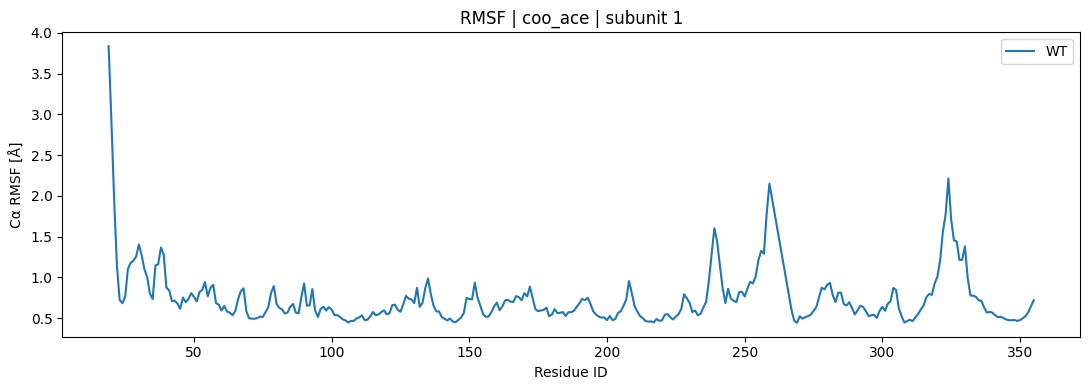

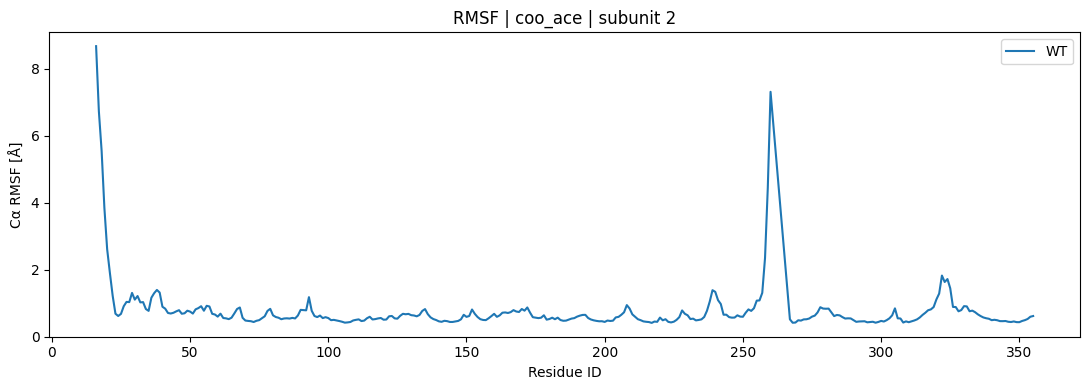

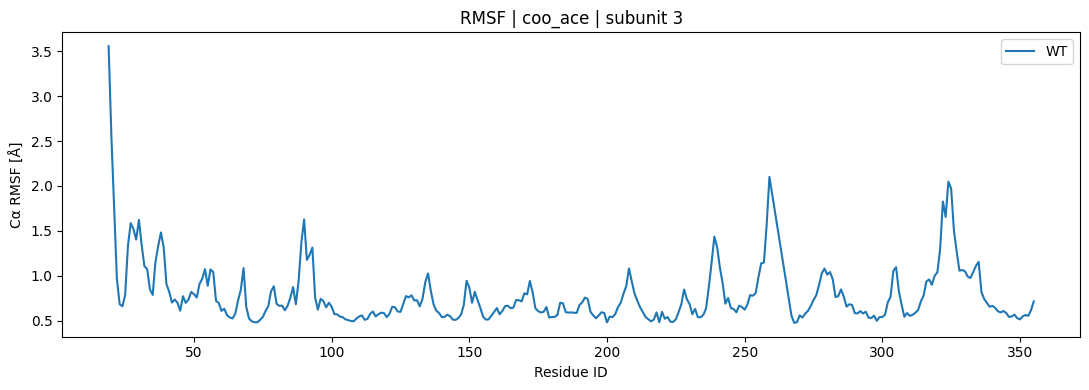

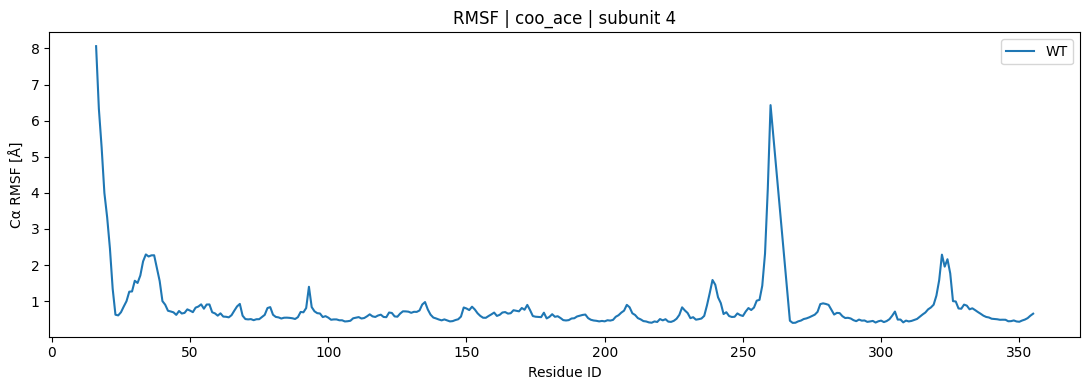

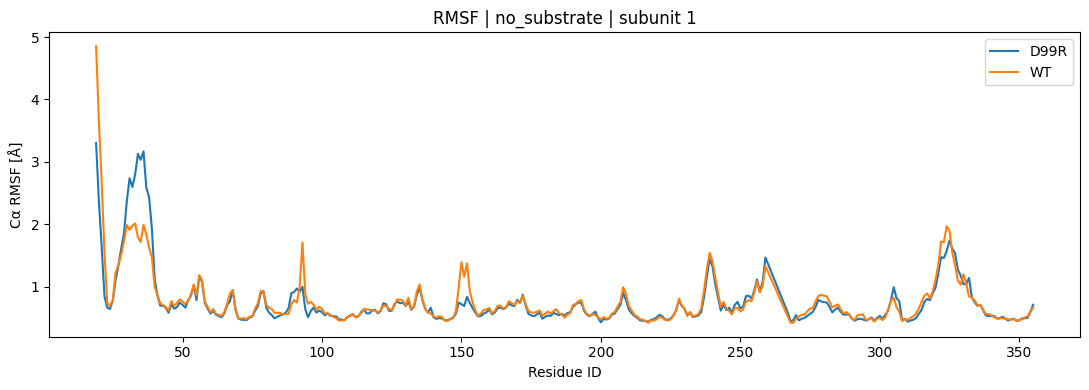

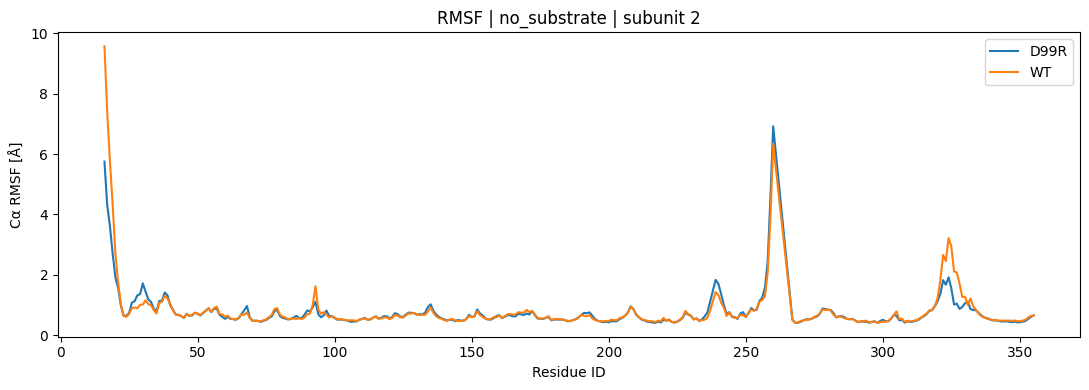

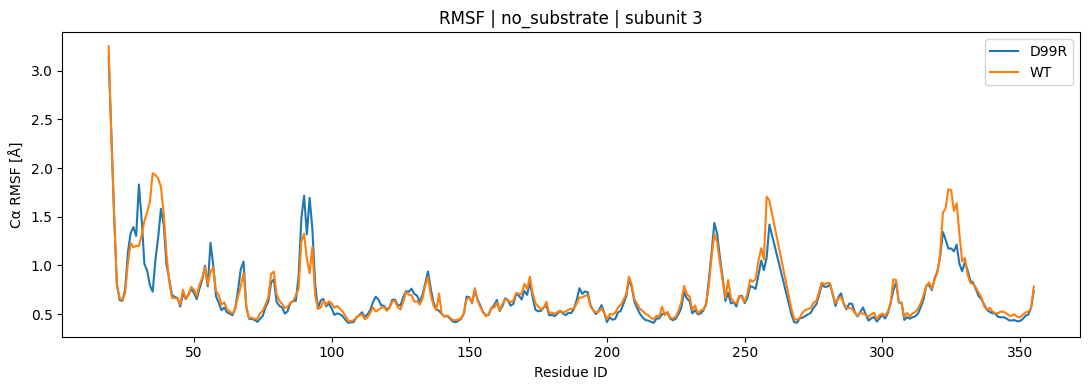

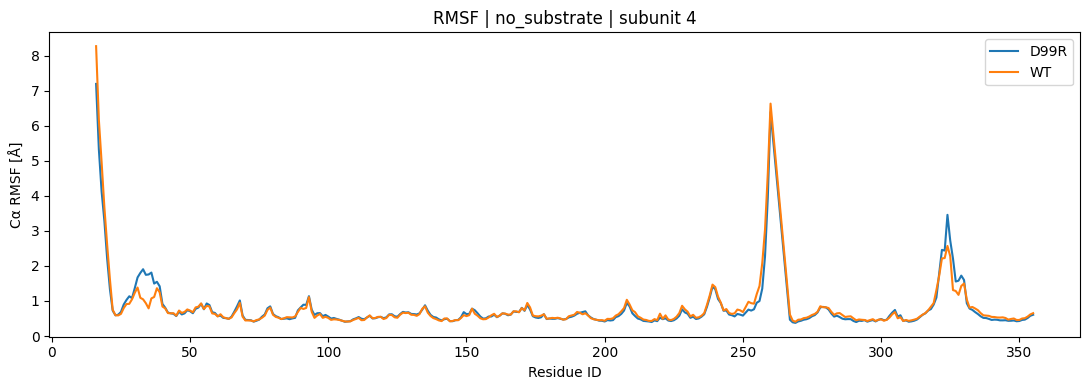

In [47]:
for condition_name in sorted(rmsf_variant_by_condition["condition"].unique()):

    condition_df = rmsf_variant_by_condition[
        rmsf_variant_by_condition["condition"] == condition_name
    ]

    for subunit_id in sorted(condition_df["subunit_id"].unique()):

        subunit_df = condition_df[
            condition_df["subunit_id"] == subunit_id
        ]

        plt.figure(figsize=(11, 4))

        for variant in sorted(subunit_df["variant"].unique()):

            plot_df = subunit_df[
                subunit_df["variant"] == variant
            ].sort_values("resid")

            plt.plot(
                plot_df["resid"],
                plot_df["rmsf_mean_A"],
                label=variant,
                linewidth=1.5,
            )

        plt.xlabel("Residue ID")
        plt.ylabel("Cα RMSF [Å]")
        plt.title(f"RMSF | {condition_name} | subunit {subunit_id}")
        plt.legend()
        plt.tight_layout()
        plt.show()

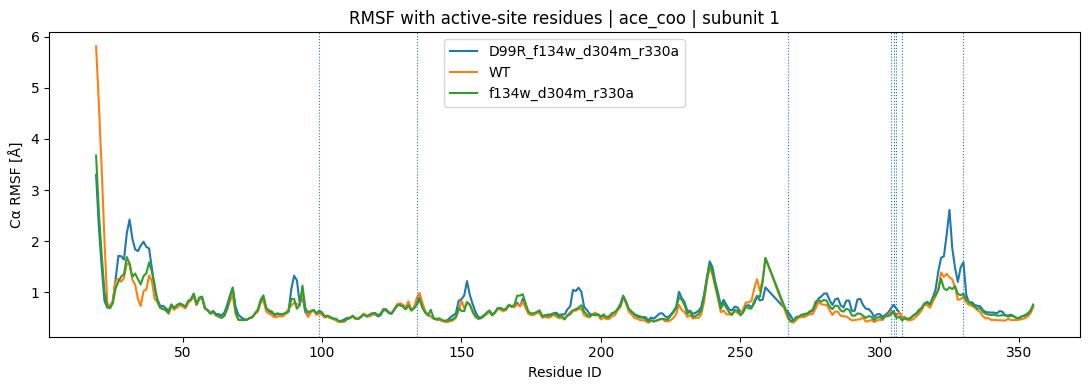

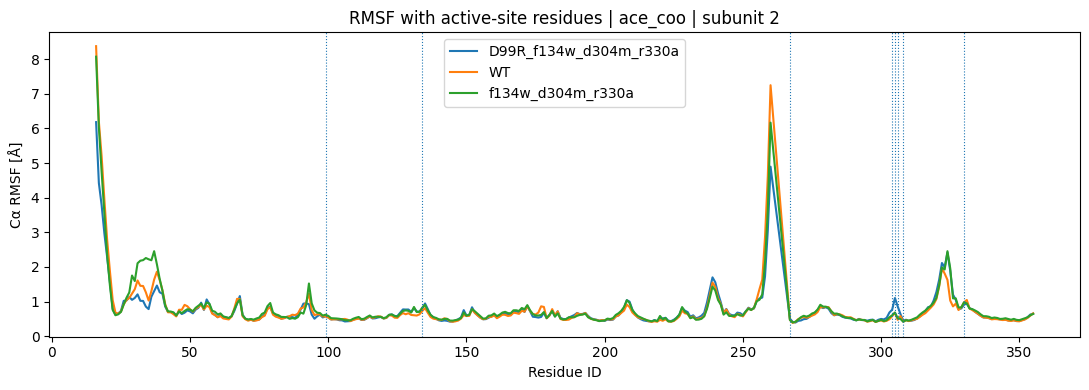

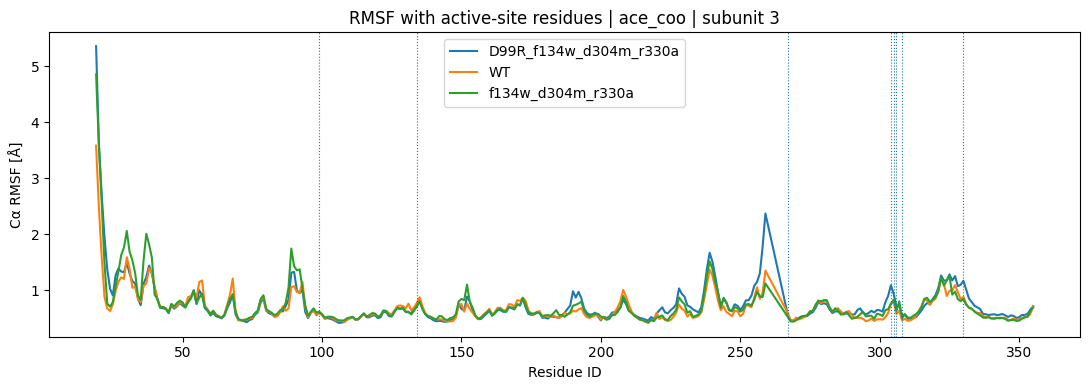

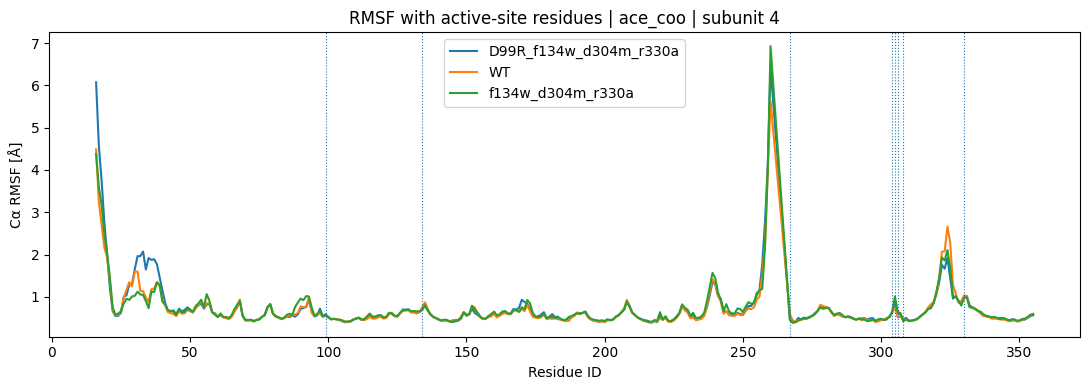

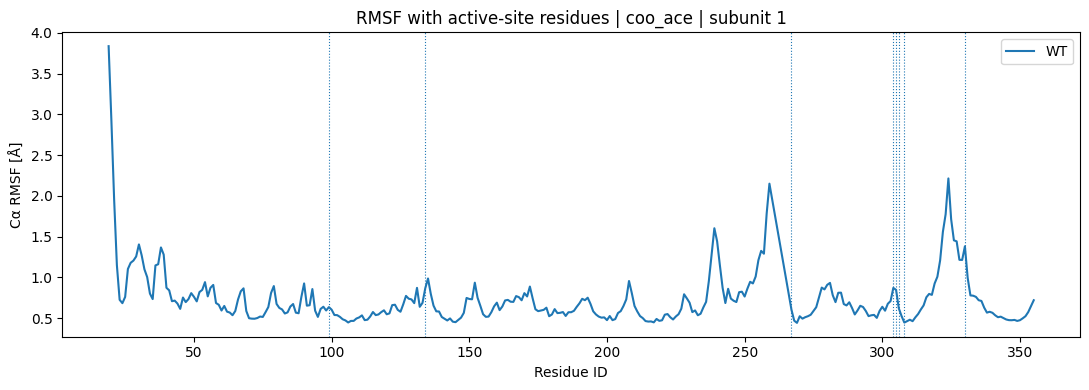

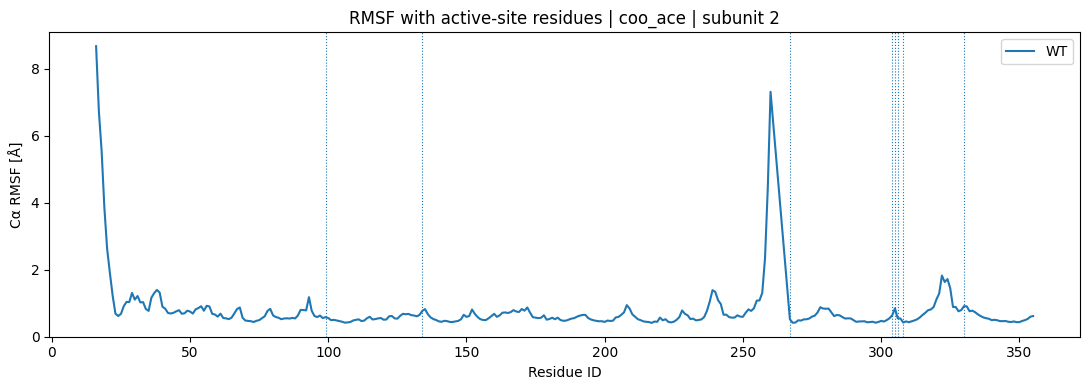

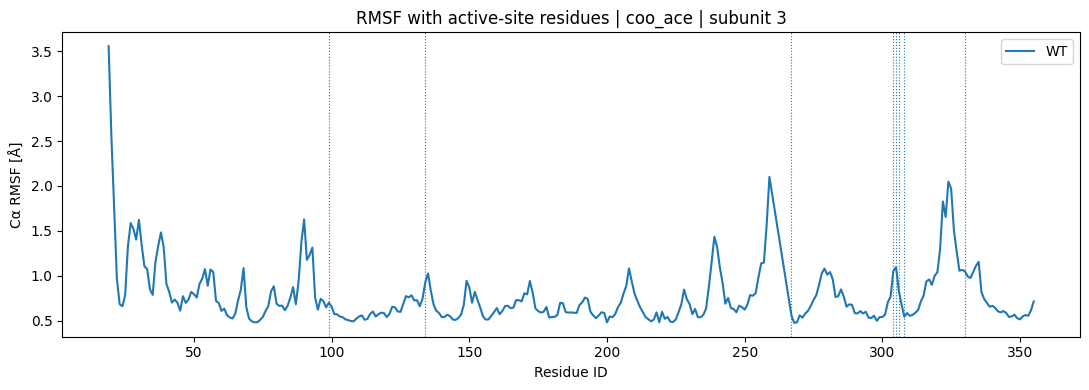

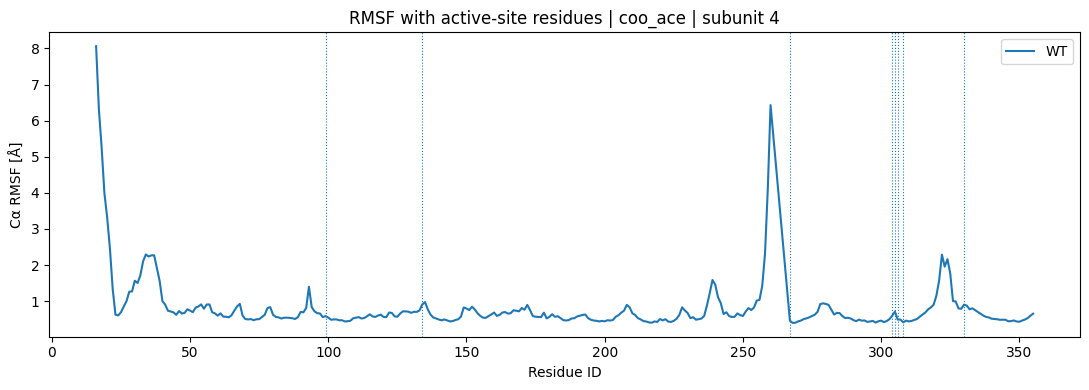

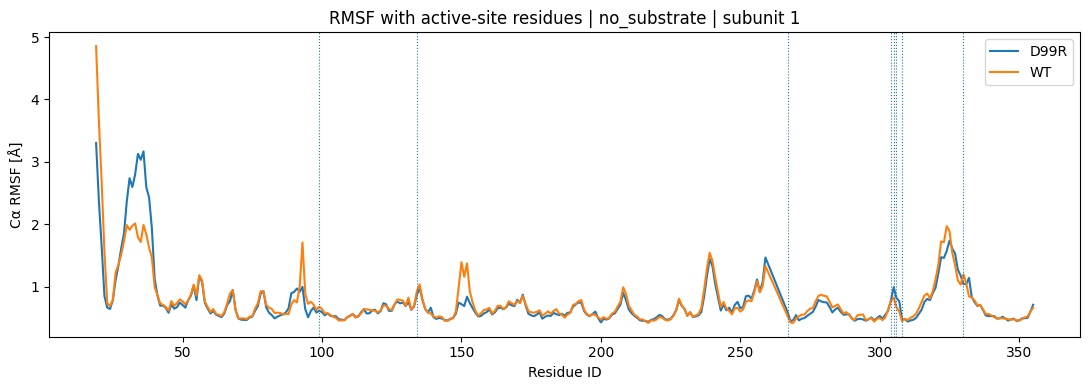

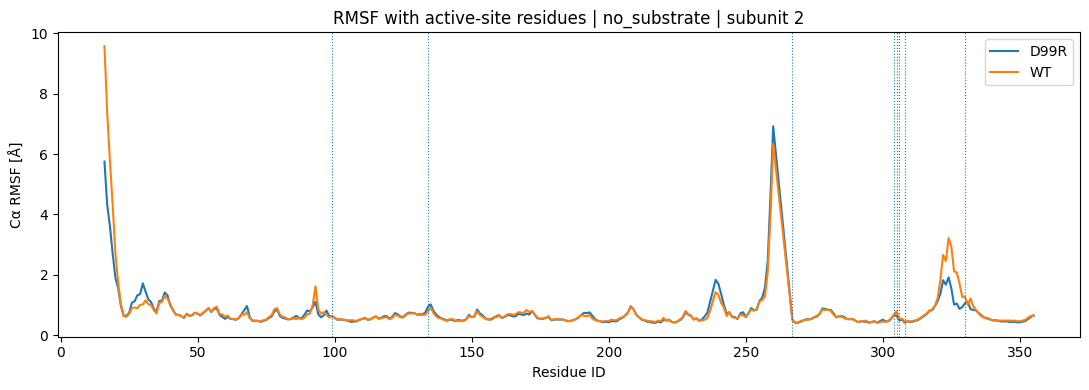

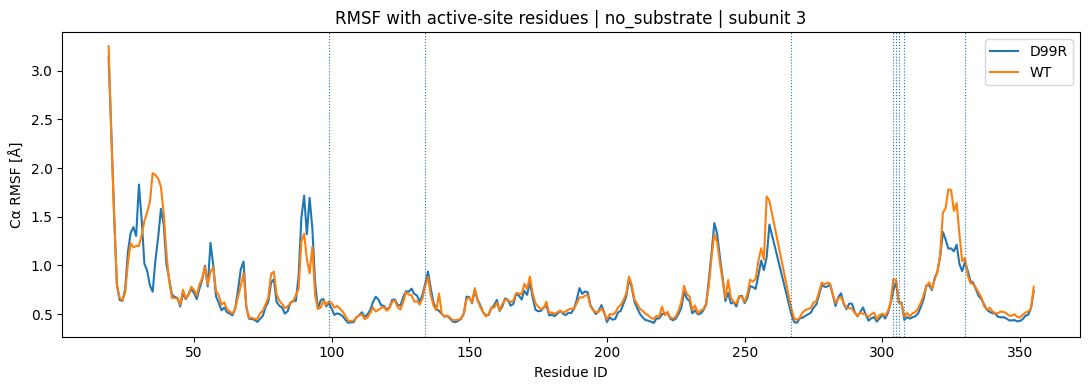

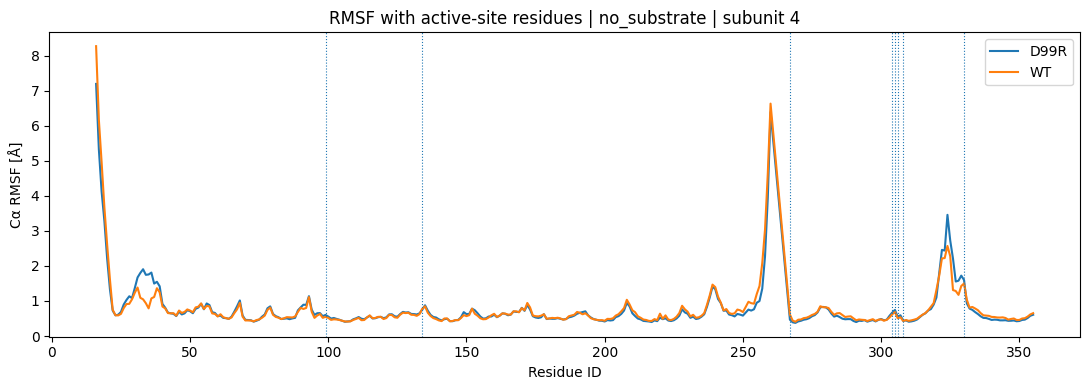

In [48]:
highlight_residues = [99, 134, 267, 304, 305, 306, 308, 330]

for condition_name in sorted(rmsf_variant_by_condition["condition"].unique()):

    condition_df = rmsf_variant_by_condition[
        rmsf_variant_by_condition["condition"] == condition_name
    ].copy()

    for subunit_id in sorted(condition_df["subunit_id"].unique()):

        subunit_df = condition_df[
            condition_df["subunit_id"] == subunit_id
        ].copy()

        plt.figure(figsize=(11, 4))

        for variant in sorted(subunit_df["variant"].unique()):

            plot_df = subunit_df[
                subunit_df["variant"] == variant
            ].sort_values("resid")

            plt.plot(
                plot_df["resid"],
                plot_df["rmsf_mean_A"],
                label=variant,
                linewidth=1.5,
            )

        for resid in highlight_residues:
            plt.axvline(resid, linestyle=":", linewidth=0.8)

        plt.xlabel("Residue ID")
        plt.ylabel("Cα RMSF [Å]")
        plt.title(
            f"RMSF with active-site residues | {condition_name} | subunit {subunit_id}"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

In [49]:
TOP_N_PER_VARIANT = 10

peak_df_per_variant = (
    rmsf_variant_by_condition
    .groupby(["condition", "variant"], group_keys=False)
    .apply(
        lambda x: x.nlargest(
            TOP_N_PER_VARIANT,
            "rmsf_mean_A",
        )
    )
    .reset_index(drop=True)
)

peak_df_per_variant = peak_df_per_variant[
    [
        "condition",
        "variant",
        "subunit_id",
        "resid",
        "resname",
        "rmsf_mean_A",
        "rmsf_sd_A",
        "n_replicates",
    ]
]

display(peak_df_per_variant)

/tmp/dwp46550/login23-1_406779/ipykernel_140698/2553374174.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmsf_variant_by_condition


,condition,variant,subunit_id,resid,resname,rmsf_mean_A,rmsf_sd_A,n_replicates
0,ace_coo,D99R_f134w_d304m_r330a,4,260,PRO,6.419956,0.347524,3
1,ace_coo,D99R_f134w_d304m_r330a,2,16,ILE,6.180846,3.339569,3
2,ace_coo,D99R_f134w_d304m_r330a,4,16,ILE,6.071845,4.109070,3
3,ace_coo,D99R_f134w_d304m_r330a,3,19,ASP,5.359540,1.645447,3
4,ace_coo,D99R_f134w_d304m_r330a,2,260,PRO,4.894817,1.267059,3
5,ace_coo,D99R_f134w_d304m_r330a,4,17,ALA,4.564840,3.037345,3
6,ace_coo,D99R_f134w_d304m_r330a,2,17,ALA,4.421688,2.295693,3
7,ace_coo,D99R_f134w_d304m_r330a,4,259,PRO,4.129069,0.657067,3
8,ace_coo,D99R_f134w_d304m_r330a,2,18,VAL,3.782246,1.852054,3
9,ace_coo,D99R_f134w_d304m_r330a,4,18,VAL,3.746679,2.557183,3


In [54]:
from MDAnalysis.lib.distances import distance_array

CONTACT_CUTOFF_A = 4.0
STRIDE_CONTACTS = 10
SUBSTRATE_RESNAMES = ("UNL1", "SUB", "LIG")


def detect_substrate_resname(u, substrate_resnames=SUBSTRATE_RESNAMES):
    for resname in substrate_resnames:
        if u.select_atoms(f"resname {resname}").n_atoms > 0:
            return resname
    return None


def infer_subunit_ids_from_resid_reset_ca(ca_atoms):
    resids = ca_atoms.resids
    subunit_ids = np.ones(len(ca_atoms), dtype=int)

    current_subunit = 1

    for i in range(1, len(ca_atoms)):
        if resids[i] < resids[i - 1]:
            current_subunit += 1
        subunit_ids[i] = current_subunit

    return subunit_ids


def build_atom_to_subunit_map(u):
    """
    Builds a mapping from residue identity/order to artificial subunit IDs.
    Assumes subunits are stored consecutively and residue numbering resets.
    """

    ca = u.select_atoms("protein and name CA")

    if ca.n_atoms == 0:
        raise ValueError("No protein C-alpha atoms found.")

    ca_subunit_ids = infer_subunit_ids_from_resid_reset_ca(ca)

    ca_table = pd.DataFrame({
        "resindex": ca.resindices,
        "subunit_id": ca_subunit_ids,
    })

    return dict(zip(ca_table["resindex"], ca_table["subunit_id"]))


def compute_substrate_contacts_for_replicate(
    u,
    variant,
    condition,
    replicate,
    cutoff=CONTACT_CUTOFF_A,
    stride=STRIDE_CONTACTS,
):
    substrate_resname = detect_substrate_resname(u)

    if substrate_resname is None:
        print(f"No substrate found: {variant} | {condition} | replicate {replicate}")
        return pd.DataFrame()

    protein = u.select_atoms("protein")
    substrate = u.select_atoms(f"resname {substrate_resname}")

    if protein.n_atoms == 0:
        raise ValueError("Protein selection returned 0 atoms.")

    if substrate.n_atoms == 0:
        raise ValueError("Substrate selection returned 0 atoms.")

    resindex_to_subunit = build_atom_to_subunit_map(u)

    protein_residues = protein.residues

    rows = []

    for ts in u.trajectory[::stride]:

        d = distance_array(
            protein.positions,
            substrate.positions,
        )

        contacting_atom_indices = np.where(np.any(d <= cutoff, axis=1))[0]

        if len(contacting_atom_indices) == 0:
            continue

        contacting_atoms = protein[contacting_atom_indices]
        contacting_residues = contacting_atoms.residues

        for residue in contacting_residues:

            subunit_id = resindex_to_subunit.get(residue.resindex, np.nan)

            rows.append({
                "variant": variant,
                "condition": condition,
                "replicate": replicate,
                "frame": ts.frame,
                "time_ps": ts.time,
                "substrate_resname": substrate_resname,
                "cutoff_A": cutoff,
                "subunit_id": subunit_id,
                "resid": residue.resid,
                "resname": residue.resname,
                "resindex": residue.resindex,
                "contact": 1,
            })

    contact_df = pd.DataFrame(rows)

    return contact_df

In [55]:
all_contacts = []

for variant_dir in BASE.iterdir():

    if not variant_dir.is_dir():
        continue

    variant = variant_dir.name

    for condition_dir in variant_dir.iterdir():

        if not condition_dir.is_dir() or condition_dir.name == "no_substrate":
            continue

        condition = condition_dir.name

        for xtc_file in sorted(condition_dir.glob("md_center_*.xtc")):

            match = re.search(r"md_center_(\d+)", xtc_file.stem)

            if match is None:
                print(f"Could not detect replicate number from {xtc_file.name}")
                continue

            replicate = int(match.group(1))
            pdb_file = condition_dir / f"md_center_{replicate}.pdb"

            if not pdb_file.exists():
                print(f"Missing matching PDB for {xtc_file.name}")
                continue

            print(f"Processing contacts: {variant} | {condition} | replicate {replicate}")

            u = mda.Universe(str(pdb_file), str(xtc_file))

            contact_df = compute_substrate_contacts_for_replicate(
                u=u,
                variant=variant,
                condition=condition,
                replicate=replicate,
                cutoff=CONTACT_CUTOFF_A,
                stride=STRIDE_CONTACTS,
            )

            if not contact_df.empty:
                all_contacts.append(contact_df)

substrate_contacts_framewise = pd.concat(all_contacts, ignore_index=True)

substrate_contacts_framewise.to_csv(
    OUT_DIR / "substrate_contacts_framewise.csv",
    index=False,
)

substrate_contacts_framewise.head()

Processing contacts: f134w_d304m_r330a | ace_coo | replicate 1
Processing contacts: f134w_d304m_r330a | ace_coo | replicate 2
Processing contacts: f134w_d304m_r330a | ace_coo | replicate 3
Processing contacts: WT | coo_ace | replicate 1
Processing contacts: WT | coo_ace | replicate 2
Processing contacts: WT | coo_ace | replicate 3
Processing contacts: WT | ace_coo | replicate 1
Processing contacts: WT | ace_coo | replicate 2
Processing contacts: WT | ace_coo | replicate 3
Processing contacts: D99R_f134w_d304m_r330a | ace_coo | replicate 1
Processing contacts: D99R_f134w_d304m_r330a | ace_coo | replicate 2
Processing contacts: D99R_f134w_d304m_r330a | ace_coo | replicate 3


,variant,condition,replicate,frame,time_ps,substrate_resname,cutoff_A,subunit_id,resid,resname,resindex,contact
0,f134w_d304m_r330a,ace_coo,1,0,0.0,UNL1,4.0,1,28,PRO,10,1
1,f134w_d304m_r330a,ace_coo,1,0,0.0,UNL1,4.0,1,30,PHE,12,1
2,f134w_d304m_r330a,ace_coo,1,0,0.0,UNL1,4.0,1,90,GLY,72,1
3,f134w_d304m_r330a,ace_coo,1,0,0.0,UNL1,4.0,1,91,ALA,73,1
4,f134w_d304m_r330a,ace_coo,1,0,0.0,UNL1,4.0,1,92,VAL,74,1


In [56]:
def aggregate_contact_frequency_per_replicate(
    contact_df,
    stride=STRIDE_CONTACTS,
):
    """
    Calculates residue contact frequency per replicate.
    Frequency = frames with contact / total analyzed frames for that replicate.
    """

    total_frames = (
        contact_df
        .groupby(["variant", "condition", "replicate"], as_index=False)
        ["frame"]
        .nunique()
        .rename(columns={"frame": "n_contact_frames_observed"})
    )

    contact_frequency = (
        contact_df
        .groupby(
            [
                "variant",
                "condition",
                "replicate",
                "substrate_resname",
                "cutoff_A",
                "subunit_id",
                "resid",
                "resname",
                "resindex",
            ],
            as_index=False,
        )
        .agg(
            n_contact_frames=("frame", "nunique"),
        )
    )

    n_analyzed_frames = (
        rmsd_framewise
        .groupby(["variant", "condition", "replicate"], as_index=False)
        .agg(n_analyzed_frames=("frame_index", "count"))
    )

    contact_frequency = contact_frequency.merge(
        n_analyzed_frames,
        on=["variant", "condition", "replicate"],
        how="left",
    )

    contact_frequency["contact_frequency"] = (
        contact_frequency["n_contact_frames"] /
        contact_frequency["n_analyzed_frames"]
    )

    return contact_frequency


substrate_contacts_replicate = aggregate_contact_frequency_per_replicate(
    substrate_contacts_framewise
)

substrate_contacts_replicate.to_csv(
    OUT_DIR / "substrate_contacts_replicate.csv",
    index=False,
)

substrate_contacts_replicate.head()

,variant,condition,replicate,substrate_resname,cutoff_A,subunit_id,resid,resname,resindex,n_contact_frames,n_analyzed_frames,contact_frequency
0,D99R_f134w_d304m_r330a,ace_coo,1,UNL1,4.0,1,26,GLY,8,1,751,0.001332
1,D99R_f134w_d304m_r330a,ace_coo,1,UNL1,4.0,1,27,PRO,9,25,751,0.033289
2,D99R_f134w_d304m_r330a,ace_coo,1,UNL1,4.0,1,28,PRO,10,413,751,0.549933
3,D99R_f134w_d304m_r330a,ace_coo,1,UNL1,4.0,1,29,VAL,11,176,751,0.234354
4,D99R_f134w_d304m_r330a,ace_coo,1,UNL1,4.0,1,30,PHE,12,289,751,0.384820


In [57]:
substrate_contacts_variant = (
    substrate_contacts_replicate
    .groupby(
        [
            "condition",
            "variant",
            "substrate_resname",
            "cutoff_A",
            "subunit_id",
            "resid",
            "resname",
        ],
        as_index=False,
    )
    .agg(
        contact_frequency_mean=("contact_frequency", "mean"),
        contact_frequency_sd=("contact_frequency", "std"),
        n_replicates=("replicate", "count"),
    )
)

substrate_contacts_variant.to_csv(
    OUT_DIR / "substrate_contacts_variant_by_condition.csv",
    index=False,
)

substrate_contacts_variant.sort_values(
    "contact_frequency_mean",
    ascending=False,
).head(30)

,condition,variant,substrate_resname,cutoff_A,subunit_id,resid,resname,contact_frequency_mean,contact_frequency_sd,n_replicates
114,ace_coo,WT,UNL1,4.0,2,139,LEU,1.000000,0.000000,3
228,coo_ace,WT,UNL1,4.0,2,98,TYR,1.000000,0.000000,3
17,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,1,146,TYR,1.000000,0.000000,3
16,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,1,145,ILE,1.000000,0.000000,3
217,coo_ace,WT,UNL1,4.0,1,267,THR,1.000000,0.000000,3
145,ace_coo,f134w_d304m_r330a,UNL1,4.0,1,146,TYR,1.000000,0.000000,3
205,coo_ace,WT,UNL1,4.0,1,146,TYR,1.000000,0.000000,3
53,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,2,139,LEU,1.000000,0.000000,3
33,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,1,267,THR,1.000000,0.000000,3
196,coo_ace,WT,UNL1,4.0,1,91,ALA,1.000000,0.000000,3


In [58]:
TOP_N = 20

top_contacts = (
    substrate_contacts_variant
    .groupby(["condition", "variant"], group_keys=False)
    .apply(lambda x: x.nlargest(TOP_N, "contact_frequency_mean"))
    .reset_index(drop=True)
)

display(
    top_contacts[
        [
            "condition",
            "variant",
            "subunit_id",
            "resid",
            "resname",
            "contact_frequency_mean",
            "contact_frequency_sd",
            "n_replicates",
        ]
    ]
)

/tmp/dwp46550/login23-1_406779/ipykernel_140698/1532625647.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  substrate_contacts_variant


,condition,variant,subunit_id,resid,resname,contact_frequency_mean,contact_frequency_sd,n_replicates
0,ace_coo,D99R_f134w_d304m_r330a,1,145,ILE,1.000000,0.000000,3
1,ace_coo,D99R_f134w_d304m_r330a,1,146,TYR,1.000000,0.000000,3
2,ace_coo,D99R_f134w_d304m_r330a,1,267,THR,1.000000,0.000000,3
3,ace_coo,D99R_f134w_d304m_r330a,2,139,LEU,1.000000,0.000000,3
4,ace_coo,D99R_f134w_d304m_r330a,2,98,TYR,0.999556,0.000769,3
...,...,...,...,...,...,...,...,...
75,coo_ace,WT,1,307,GLY,0.974257,0.037881,3
76,coo_ace,WT,3,330,ARG,0.969818,0.024274,3
77,coo_ace,WT,2,100,PHE,0.774523,0.065940,3
78,coo_ace,WT,3,331,LEU,0.727474,0.338429,3


In [59]:
important_residues = [91, 98, 99, 111, 134, 137, 139, 144, 146, 267, 304, 305, 306, 308, 330]

important_contacts = substrate_contacts_variant[
    substrate_contacts_variant["resid"].isin(important_residues)
].copy()

important_contacts.sort_values(
    "contact_frequency_mean",
    ascending=False,
)

,condition,variant,substrate_resname,cutoff_A,subunit_id,resid,resname,contact_frequency_mean,contact_frequency_sd,n_replicates
33,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,1,267,THR,1.000000,0.000000,3
17,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,1,146,TYR,1.000000,0.000000,3
110,ace_coo,WT,UNL1,4.0,2,134,PHE,1.000000,0.000000,3
80,ace_coo,WT,UNL1,4.0,1,146,TYR,1.000000,0.000000,3
53,ace_coo,D99R_f134w_d304m_r330a,UNL1,4.0,2,139,LEU,1.000000,0.000000,3
233,coo_ace,WT,UNL1,4.0,2,134,PHE,1.000000,0.000000,3
176,ace_coo,f134w_d304m_r330a,UNL1,4.0,2,134,TRP,1.000000,0.000000,3
145,ace_coo,f134w_d304m_r330a,UNL1,4.0,1,146,TYR,1.000000,0.000000,3
114,ace_coo,WT,UNL1,4.0,2,139,LEU,1.000000,0.000000,3
196,coo_ace,WT,UNL1,4.0,1,91,ALA,1.000000,0.000000,3


In [ ]:
from MDAnalysis.lib.distances import distance_array
import pandas as pd
import numpy as np

def get_thr267_og1_candidates(u):
    og_atoms = u.select_atoms("resid 267 and name OG1")
    rows = []

    for i, atom in enumerate(og_atoms, start=1):
        rows.append({
            "thr_candidate": i,
            "atom_index": atom.index,
            "resid": atom.resid,
            "resname": atom.resname,
            "atom_name": atom.name,
        })

    return og_atoms, pd.DataFrame(rows)


def scan_thr267_og1_to_substrate(u, stride=50):
    thr_og_atoms, thr_table = get_thr267_og1_candidates(u)
    substrate = u.select_atoms("resname UNL1 and not name H*")

    rows = []

    for ts in u.trajectory[::stride]:
        d = distance_array(thr_og_atoms.positions, substrate.positions)

        for i, thr_atom in enumerate(thr_og_atoms):
            min_idx = np.argmin(d[i])
            sub_atom = substrate[min_idx]

            rows.append({
                "frame": ts.frame,
                "time_ps": ts.time,
                "thr_candidate": i + 1,
                "thr_atom_index": thr_atom.index,
                "nearest_sub_atom_index": sub_atom.index,
                "nearest_sub_atom_name": sub_atom.name,
                "nearest_sub_atom_resname": sub_atom.resname,
                "min_distance_A": d[i, min_idx],
            })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby(
            [
                "thr_candidate",
                "thr_atom_index",
                "nearest_sub_atom_name",
            ],
            as_index=False,
        )
        .agg(
            mean_min_distance_A=("min_distance_A", "mean"),
            min_distance_A=("min_distance_A", "min"),
            n_frames=("frame", "count"),
        )
        .sort_values("mean_min_distance_A")
    )

    return thr_table, df, summary


thr_table, thr_scan_framewise, thr_scan_summary = scan_thr267_og1_to_substrate(
    u,
    stride=50,
)

def find_catalytic_thr267_og1(
    u,
    substrate_selection="resname UNL1 and not name H*",
):
    """
    Finds the Thr267 OG1 atom that is closest to the substrate
    in the current Universe.
    """

    thr_og_atoms = u.select_atoms("resid 267 and name OG1")
    substrate = u.select_atoms(substrate_selection)

    if thr_og_atoms.n_atoms == 0:
        raise ValueError("No Thr267 OG1 atoms found.")

    if substrate.n_atoms == 0:
        raise ValueError("No substrate atoms found.")

    d = distance_array(
        thr_og_atoms.positions,
        substrate.positions,
    )

    min_dist_per_thr = d.min(axis=1)
    best_idx = np.argmin(min_dist_per_thr)

    return thr_og_atoms[best_idx]
display(thr_table)
display(thr_scan_summary.head(20))

,thr_candidate,atom_index,resid,resname,atom_name
0,1,3501,267,THR,OG1
1,2,8368,267,THR,OG1
2,3,13176,267,THR,OG1
3,4,18043,267,THR,OG1


,thr_candidate,thr_atom_index,nearest_sub_atom_name,mean_min_distance_A,min_distance_A,n_frames
6,1,3501,C7,3.094480,3.094480,1
5,1,3501,C6,3.245503,3.208491,4
7,1,3501,N1,3.295464,2.800750,13
4,1,3501,C5,3.386640,3.386640,1
2,1,3501,C3,3.824366,3.824366,1
0,1,3501,C1,3.932525,3.516423,2
3,1,3501,C4,4.152444,3.369879,118
1,1,3501,C2,4.235957,3.783307,11
16,2,8368,O2,22.530606,22.530606,1
18,2,8368,O4,22.583572,21.897551,2


In [71]:
thr_atom = find_catalytic_thr267_og1(u)
CATALYTIC_SUBSTRATE_C_SELECTION = "resname UNL1 and name C6"

PRODUCTIVE_DISTANCE_CUTOFF_A = 3.5
STRIDE_GEOMETRY = 10

In [72]:
def compute_catalytic_productive_states(
    u,
    variant,
    condition,
    replicate,
    substrate_c_selection="resname UNL1 and name C6",
    productive_cutoff_A=3.5,
    stride=10,
):

    thr_atom = find_catalytic_thr267_og1(u)

    substrate_atom = u.select_atoms(substrate_c_selection)

    if substrate_atom.n_atoms != 1:
        raise ValueError(
            f"Substrate selection must return exactly 1 atom, got "
            f"{substrate_atom.n_atoms}: {substrate_c_selection}"
        )

    rows = []

    for ts in u.trajectory[::stride]:

        dist = distance_array(
            thr_atom.position.reshape(1, 3),
            substrate_atom.positions,
        )[0, 0]

        rows.append({
            "variant": variant,
            "condition": condition,
            "replicate": replicate,
            "frame": ts.frame,
            "time_ps": ts.time,
            "thr267_atom_index": thr_atom.index,
            "thr267_to_C6_distance_A": dist,
            "productive_state": dist <= productive_cutoff_A,
            "productive_cutoff_A": productive_cutoff_A,
        })

    return pd.DataFrame(rows)

In [73]:
all_productive_states = []

for variant_dir in BASE.iterdir():

    if not variant_dir.is_dir():
        continue

    variant = variant_dir.name

    for condition_dir in variant_dir.iterdir():

        if (
            not condition_dir.is_dir()
            or condition_dir.name == "no_substrate"
        ):
            continue

        condition = condition_dir.name

        for xtc_file in sorted(condition_dir.glob("md_center_*.xtc")):

            match = re.search(r"md_center_(\d+)", xtc_file.stem)

            if match is None:
                continue

            replicate = int(match.group(1))

            pdb_file = condition_dir / f"md_center_{replicate}.pdb"

            if not pdb_file.exists():
                continue

            print(
                f"Processing catalytic geometry: "
                f"{variant} | {condition} | R{replicate}"
            )

            u = mda.Universe(str(pdb_file), str(xtc_file))

            geom_df = compute_catalytic_productive_states(
                u=u,
                variant=variant,
                condition=condition,
                replicate=replicate,
            )

            all_productive_states.append(geom_df)

productive_states_framewise = pd.concat(
    all_productive_states,
    ignore_index=True,
)

productive_states_framewise.head()

Processing catalytic geometry: f134w_d304m_r330a | ace_coo | R1
Processing catalytic geometry: f134w_d304m_r330a | ace_coo | R2
Processing catalytic geometry: f134w_d304m_r330a | ace_coo | R3
Processing catalytic geometry: WT | coo_ace | R1
Processing catalytic geometry: WT | coo_ace | R2
Processing catalytic geometry: WT | coo_ace | R3
Processing catalytic geometry: WT | ace_coo | R1
Processing catalytic geometry: WT | ace_coo | R2
Processing catalytic geometry: WT | ace_coo | R3
Processing catalytic geometry: D99R_f134w_d304m_r330a | ace_coo | R1
Processing catalytic geometry: D99R_f134w_d304m_r330a | ace_coo | R2
Processing catalytic geometry: D99R_f134w_d304m_r330a | ace_coo | R3


,variant,condition,replicate,frame,time_ps,thr267_atom_index,thr267_to_C6_distance_A,productive_state,productive_cutoff_A
0,f134w_d304m_r330a,ace_coo,1,0,0.0,3489,3.501613,False,3.5
1,f134w_d304m_r330a,ace_coo,1,10,200.0,3489,3.314045,True,3.5
2,f134w_d304m_r330a,ace_coo,1,20,400.0,3489,3.140610,True,3.5
3,f134w_d304m_r330a,ace_coo,1,30,600.0,3489,3.523779,False,3.5
4,f134w_d304m_r330a,ace_coo,1,40,800.0,3489,3.437269,True,3.5


In [74]:
productive_states_replicate = (
    productive_states_framewise
    .groupby(
        ["condition", "variant", "replicate"],
        as_index=False,
    )
    .agg(
        mean_distance_A=("thr267_to_C6_distance_A", "mean"),
        min_distance_A=("thr267_to_C6_distance_A", "min"),
        productive_fraction=("productive_state", "mean"),
        n_frames=("productive_state", "count"),
    )
)

productive_states_replicate

,condition,variant,replicate,mean_distance_A,min_distance_A,productive_fraction,n_frames
0,ace_coo,D99R_f134w_d304m_r330a,1,3.829991,2.974575,0.111851,751
1,ace_coo,D99R_f134w_d304m_r330a,2,4.417265,2.802664,0.279627,751
2,ace_coo,D99R_f134w_d304m_r330a,3,6.000997,3.073838,0.063915,751
3,ace_coo,WT,1,3.829369,2.933034,0.135819,751
4,ace_coo,WT,2,6.358894,3.198298,0.018642,751
5,ace_coo,WT,3,5.790632,3.167900,0.006658,751
6,ace_coo,f134w_d304m_r330a,1,6.668454,2.781959,0.081225,751
7,ace_coo,f134w_d304m_r330a,2,5.957084,2.902292,0.109188,751
8,ace_coo,f134w_d304m_r330a,3,5.014551,2.884649,0.142477,751
9,coo_ace,WT,1,9.703299,7.066070,0.000000,751


In [75]:
productive_states_variant = (
    productive_states_replicate
    .groupby(
        ["condition", "variant"],
        as_index=False,
    )
    .agg(
        productive_fraction_mean=("productive_fraction", "mean"),
        productive_fraction_sd=("productive_fraction", "std"),
        mean_distance_A=("mean_distance_A", "mean"),
        distance_sd_A=("mean_distance_A", "std"),
        n_replicates=("replicate", "count"),
    )
)

productive_states_variant

,condition,variant,productive_fraction_mean,productive_fraction_sd,mean_distance_A,distance_sd_A,n_replicates
0,ace_coo,D99R_f134w_d304m_r330a,0.151798,0.113269,4.749418,1.122970,3
1,ace_coo,WT,0.053706,0.071364,5.326298,1.327150,3
2,ace_coo,f134w_d304m_r330a,0.110963,0.030664,5.880029,0.829639,3
3,coo_ace,WT,0.000000,0.000000,9.114306,0.856617,3


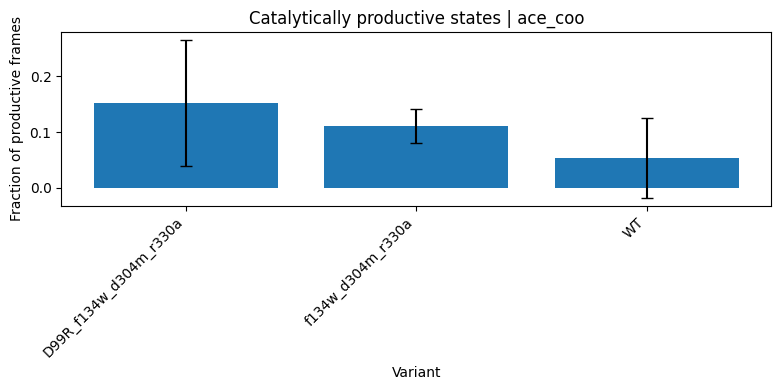

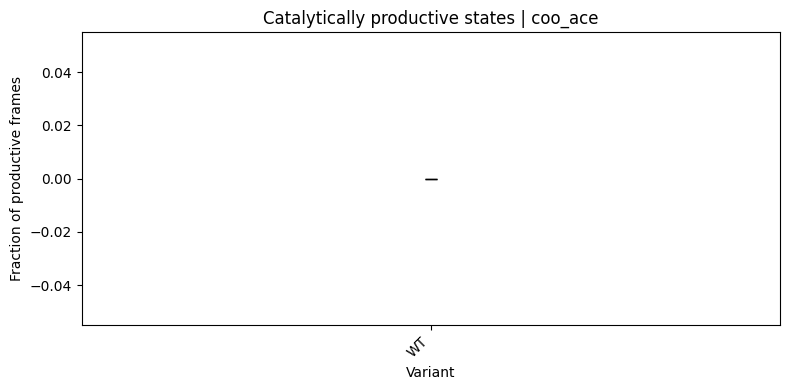

In [76]:
for condition_name in sorted(productive_states_variant["condition"].unique()):

    plot_df = productive_states_variant[
        productive_states_variant["condition"] == condition_name
    ].copy()

    plot_df = plot_df.sort_values("productive_fraction_mean", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(
        plot_df["variant"],
        plot_df["productive_fraction_mean"],
        yerr=plot_df["productive_fraction_sd"],
        capsize=4,
    )

    plt.ylabel("Fraction of productive frames")
    plt.xlabel("Variant")
    plt.title(f"Catalytically productive states | {condition_name}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()